In [1]:
# Setting up the file path
import os
os.chdir('..')

In [2]:
# Importing packages
import numpy as np
import torch
from itertools import product
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.iocrns.reaction_library import construct_mass_action_library
from RL4CRN.policies.add_reaction_from_library import AddReactionFromLibrary
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator

In [3]:
# Construct the template CRN
r1 = MassAction([], ['Z_1'], ['u_1'], [0.1])
r2 = MassAction(['X_1'], [], ['u_2'], [0.5])
r3 = MassAction(['Z_1'], ['X_1'], [None], [0.2])
crn_template = IOCRN([r1, r2, r3], output_labels=['X_1', 'Z_1'])
crn_template.compile()
print('CRN template:')
print(crn_template)

CRN template:
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1'] 
Output Species: ['X_1', 'Z_1'] 
∅ ----> Z_1;  [MAK(0.1, u_1)]
X_1 ----> ∅;  [MAK(0.5, u_2)]
Z_1 ----> X_1;  [MAK(0.2)]


In [4]:
# Construct a list of initial conditions
species_labels = ['X_1', 'X_2', 'Z_1', 'Z_2']
ic = IC(species_labels, values= [
    [10, 2, 5, 3],
    [20, 13, 10, 2],
])
x0_list = ic.get_ic(crn_template)

# Construct a list of input scenarios
input_values = [0.5, 1.0, 1.5]
u_list = [np.array(u, dtype=np.float32) for u in product(input_values, repeat=crn_template.num_inputs)]

# Construct the time horizon
time_horizon = np.linspace(0, 500.0, 1000, dtype=np.float32)

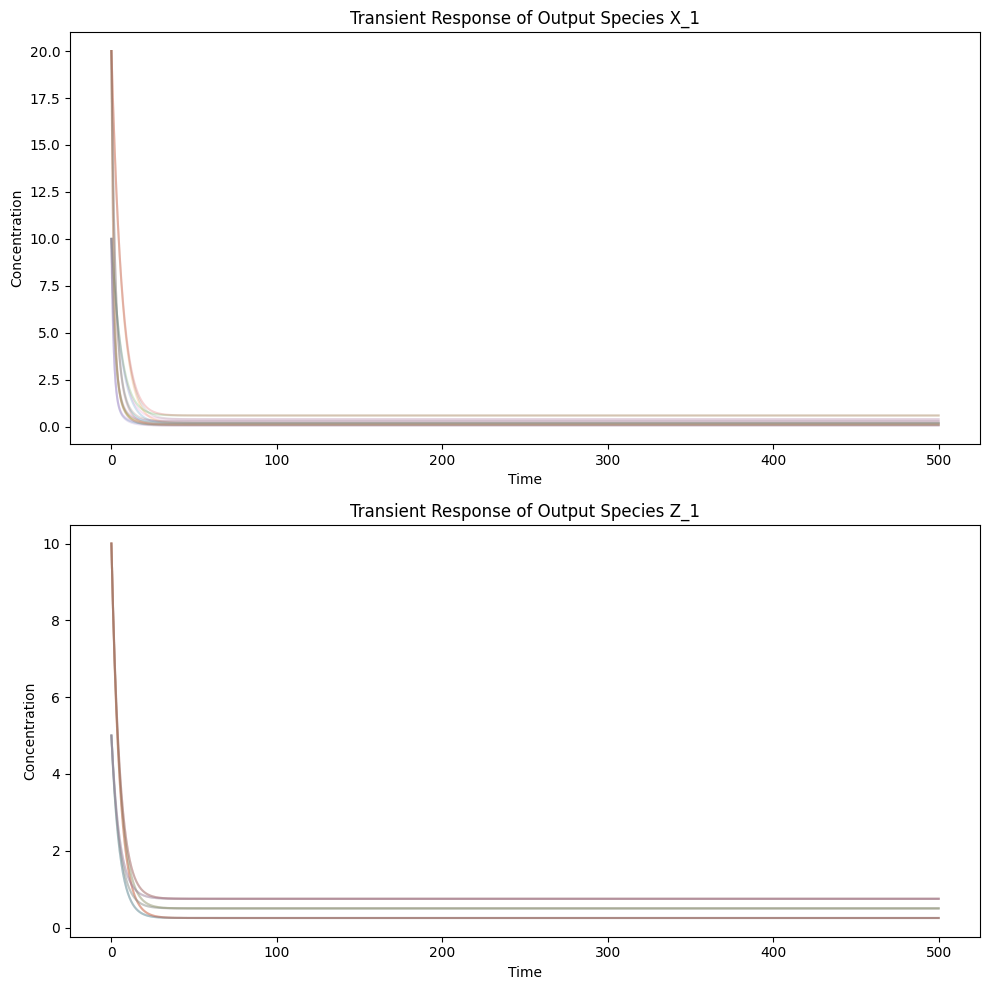

In [5]:
# Simulate the transient response of the template CRN
t, x_list, y_list, task_info = crn_template.transient_response(u_list, x0_list, time_horizon)

# Plot
fig, ax = crn_template.plot_transient_response(alpha = 0.2)

In [6]:
# Construct the reaction library
library = construct_mass_action_library(species_labels, 2)
print(library)

Number of reactions: 211
R0: ∅ ----> X_1;  [MAK(None)]
R1: ∅ ----> X_2;  [MAK(None)]
R2: ∅ ----> Z_1;  [MAK(None)]
R3: ∅ ----> Z_2;  [MAK(None)]
R4: ∅ ----> X_1 + X_1;  [MAK(None)]
R5: ∅ ----> X_1 + X_2;  [MAK(None)]
R6: ∅ ----> X_1 + Z_1;  [MAK(None)]
R7: ∅ ----> X_1 + Z_2;  [MAK(None)]
R8: ∅ ----> X_2 + X_2;  [MAK(None)]
R9: ∅ ----> X_2 + Z_1;  [MAK(None)]
R10: ∅ ----> X_2 + Z_2;  [MAK(None)]
R11: ∅ ----> Z_1 + Z_1;  [MAK(None)]
R12: ∅ ----> Z_1 + Z_2;  [MAK(None)]
R13: ∅ ----> Z_2 + Z_2;  [MAK(None)]
R14: X_1 ----> ∅;  [MAK(None)]
R15: X_1 ----> X_2;  [MAK(None)]
R16: X_1 ----> Z_1;  [MAK(None)]
R17: X_1 ----> Z_2;  [MAK(None)]
R18: X_1 ----> X_1 + X_1;  [MAK(None)]
R19: X_1 ----> X_1 + X_2;  [MAK(None)]
R20: X_1 ----> X_1 + Z_1;  [MAK(None)]
R21: X_1 ----> X_1 + Z_2;  [MAK(None)]
R22: X_1 ----> X_2 + X_2;  [MAK(None)]
R23: X_1 ----> X_2 + Z_1;  [MAK(None)]
R24: X_1 ----> X_2 + Z_2;  [MAK(None)]
R25: X_1 ----> Z_1 + Z_1;  [MAK(None)]
R26: X_1 ----> Z_1 + Z_2;  [MAK(None)]
R27: X_1 -

In [7]:
# Set the CRN context in the library
print('Before setting library context:')
print(crn_template)
print('Stoichiometry matrix:')
print(crn_template.S)
for i in range(len(crn_template.reactions)):
    print(crn_template.reactions[i].ID)

crn_template.set_library_context(library)
print('After setting library context:')
print(crn_template)
print('Stoichiometry matrix:')
print(crn_template.S)
for i in range(len(crn_template.reactions)):
    print(crn_template.reactions[i].ID)

Before setting library context:
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1'] 
Output Species: ['X_1', 'Z_1'] 
∅ ----> Z_1;  [MAK(0.1, u_1)]
X_1 ----> ∅;  [MAK(0.5, u_2)]
Z_1 ----> X_1;  [MAK(0.2)]
Stoichiometry matrix:
[[ 0. -1.  1.]
 [ 1.  0. -1.]]
None
None
None
After setting library context:
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1'] 
Output Species: ['X_1', 'Z_1'] 
∅ ----> Z_1;  [MAK(0.1, u_1)]
X_1 ----> ∅;  [MAK(0.5, u_2)]
Z_1 ----> X_1;  [MAK(0.2)]
Stoichiometry matrix:
[[ 0. -1.  1.]
 [ 1.  0. -1.]]
2
14
43


In [8]:
# Construct the observer and tensorizer
observer = ExplicitObserver(library)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tensorizer = ExplicitTensorizer(device)

In [9]:
# Observe and tensorize the state
observation = observer.observe(crn_template)
tensorized_observation = tensorizer.tensorize(observation)

reaction_multihot, params_cross_multihot, inputs_multihot = observation
print(f'Structure (shape: {reaction_multihot.shape}):')
print(reaction_multihot)
print(f'Parameters (shape: {params_cross_multihot.shape}):')
print(params_cross_multihot)
print('Inputs (shape: {}):'.format(inputs_multihot.shape))
print(inputs_multihot)
print(f'Tensorized observation (shape: {tensorized_observation.shape}):')
print(tensorized_observation)

Structure (shape: (211,)):
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Parameters (shape: (211,)):
[0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.2 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0

In [11]:
# Construct the policy neural network
p = crn_template.num_inputs
width = 1024
depth = 5
deep_layer_size = 1024*10
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
parameter_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
policy = AddReactionFromLibrary(library, p, encoder_attributes, deep_layer_size, structure_head_attributes, parameter_head_attributes, input_influence_head_attributes, allow_input_influence=False, device=device)

In [13]:
# Get action from the policy
actions, logP, entropy = policy(tensorized_observation.unsqueeze(0), mode='full')
print(f'Actions (shape: {len(actions)}):')
print(actions)
print(f'Log probabilities (shape: {logP}):')
print(logP)
print(f'Entropy (shape: {entropy}):')
print(entropy)

Actions (shape: 1):
[{'reaction index': np.int64(28), 'parameters': [0.6434847712516785]}]
Log probabilities (shape: tensor([-5.5960], device='cuda:0', grad_fn=<AddBackward0>)):
tensor([-5.5960], device='cuda:0', grad_fn=<AddBackward0>)
Entropy (shape: tensor([5.7020], device='cuda:0', grad_fn=<AddBackward0>)):
tensor([5.7020], device='cuda:0', grad_fn=<AddBackward0>)


In [14]:
# Construct the actuator
actuator = LibraryActuator(library)

In [15]:
# Construct reaction from the action
new_reaction = actuator.actuate(actions[0])
print(new_reaction)

X_2 ----> ∅;  [MAK(0.6434847712516785)]


In [16]:
# Update the CRN with the new reaction
crn = crn_template.clone()
crn.add_reaction(new_reaction)
crn.compile()
print(crn)
print('Stoichiometry matrix:')
print(crn.S)
for i in range(len(crn.reactions)):
    print(crn.reactions[i].ID)

Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'X_2', 'Z_1'] 
Output Species: ['X_1', 'Z_1'] 
∅ ----> Z_1;  [MAK(0.1, u_1)]
X_1 ----> ∅;  [MAK(0.5, u_2)]
Z_1 ----> X_1;  [MAK(0.2)]
X_2 ----> ∅;  [MAK(0.6434847712516785)]
Stoichiometry matrix:
[[ 0. -1.  1.  0.]
 [ 0.  0.  0. -1.]
 [ 1.  0. -1.  0.]]
2
14
43
28


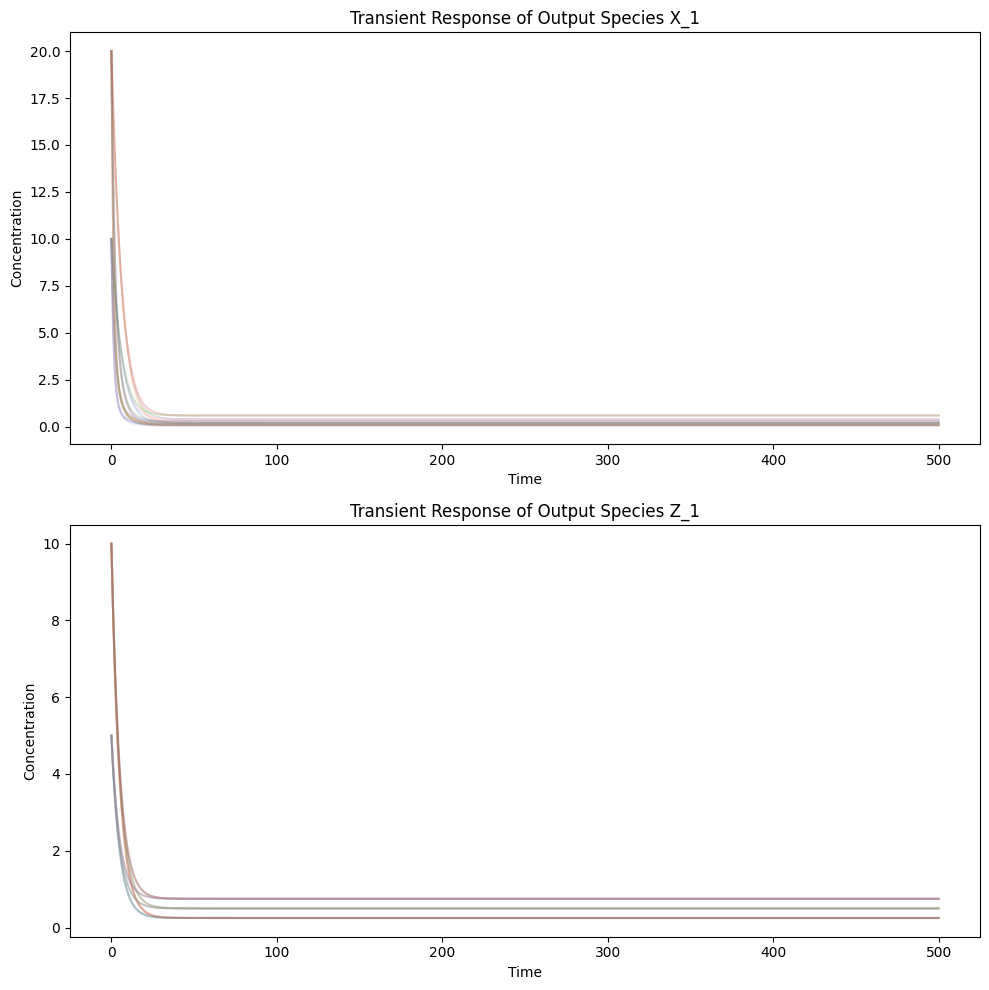

In [17]:
# Simulate the transient response of the template CRN
x0_list = ic.get_ic(crn)
crn.reset()
t, x_list, y_list, task_info = crn.transient_response(u_list, x0_list, time_horizon)

# Plot
fig, ax = crn.plot_transient_response(alpha = 0.2)